<a href="https://colab.research.google.com/github/Mukunda-art/Future_ML_02/blob/main/Support_Ticket_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (8469, 17)
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup  

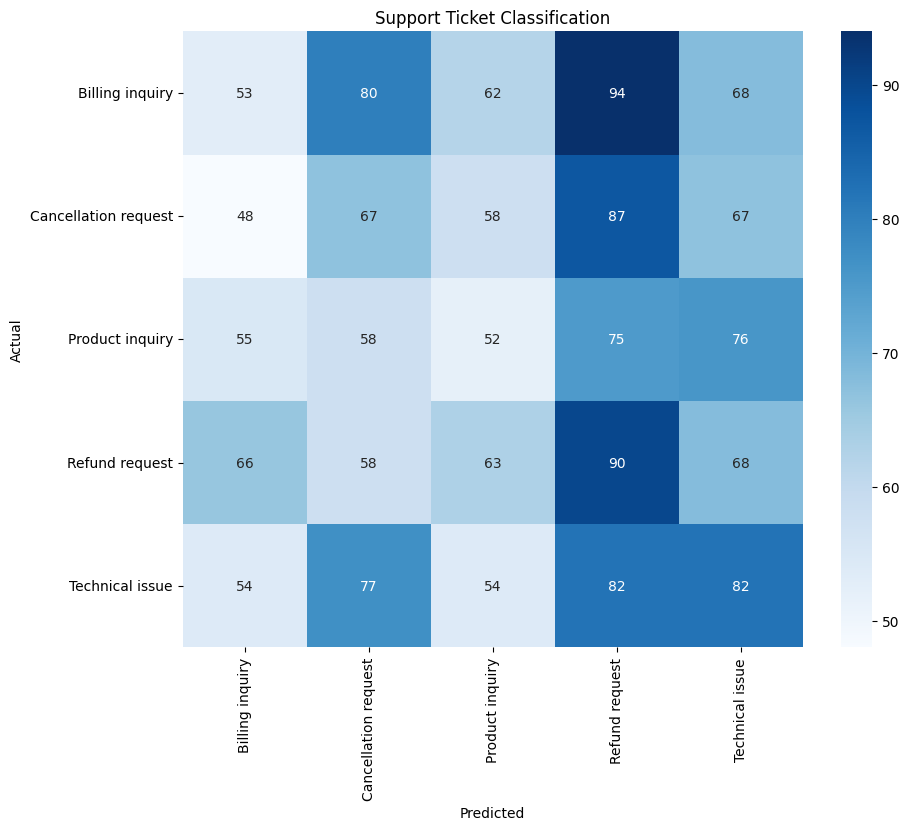


Predicted Ticket Type: Technical issue


In [8]:
# =============================
# SUPPORT TICKET CLASSIFICATION
# ==========================

import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder


# -----------------------------
# Load Dataset
# -----------------------------
# The zip file is not found, but the unzipped CSV is available.
# So, directly load the CSV file.
# zip_path = "customer_support_tickets.csv.zip"
# with zipfile.ZipFile(zip_path, "r") as z:
#     csv_name = z.namelist()[0]
#     df = pd.read_csv(z.open(csv_name))

df = pd.read_csv("/content/customer_support_tickets.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# -----------------------------
# Data Cleaning
# -----------------------------

df = df.drop_duplicates()

text_cols = ["Ticket Subject", "Ticket Description"]

for col in text_cols:
    df[col] = df[col].fillna("")

df["combined_text"] = (
    df["Ticket Subject"].astype(str)
    + " "
    + df["Ticket Description"].astype(str)
)

# Target Column
target = "Ticket Type"

df = df.dropna(subset=[target])

print("\nClasses:")
print(df[target].value_counts())


# -----------------------------
# Encode Labels
# -----------------------------

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df[target])

X = df["combined_text"]
y = df["label"]


# -----------------------------
# Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -----------------------------
# Build Model
# -----------------------------

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            max_features=5000
        )
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])


# -----------------------------
# Train
# -----------------------------

model.fit(X_train, y_train)


# -----------------------------
# Prediction
# -----------------------------

pred = model.predict(X_test)


# -----------------------------
# Evaluation
# -----------------------------

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred,
        target_names=encoder.classes_
    )
)


# -----------------------------
# Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Support Ticket Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# -----------------------------
# Sample Prediction
# -----------------------------

sample = """
My payment failed and money was deducted
"""

prediction = model.predict([sample])[0]

print(
    "\nPredicted Ticket Type:",
    encoder.inverse_transform([prediction])[0]
)